<a href="https://colab.research.google.com/github/cyeef/Data-Science-Portfolio-C21-/blob/main/Projects/WHO%20Dataset/TB_worldwide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement

This dataset is sourced from the World Health Organization (WHO) Global
Tuberculosis Programme and contains TB burden estimates and comorbidity
indicators by country and year. The goal is to build a binary classification
model predicting whether a country-year achieves high case detection rate
(≥70%, target = 1) or low case detection rate (<70%, target = 0), using
Gaussian Naive Bayes as the initial classifier. This is a supervised binary
classification problem — the target variable is engineered from WHO's reported
case detection rate, a health system performance metric rather than a raw
disease-burden measure.

In [1]:
# import panda and matplot
import pandas as pd
import matplotlib.pyplot as plt

## Data
Data Collection loading the data, pd.read_csv(), df.head(), df.tail(), df.info(), df.describe()

In [2]:
# this is my data from Free Public Data Sets for Analysis - pd.read_csv turns file into a data fram
turb_by_country = pd.read_csv('https://public.tableau.com/app/sample-data/TB_Burden_Country.csv?_gl=1*mmud84*_ga*MTQyNzExMTAxMy4xNzc5NDc2MDcy*_ga_8YLN0SNXVS*czE3Nzk0NzYwNzAkbzEkZzEkdDE3Nzk0NzYwODgkajYwJGwwJGgw*_gcl_au*MTQ2MzMyMTcxOC4xNzc5NDc2MDcy')
# type() determines what is the object (int, string, float etc)
type(turb_by_country)


pandas.core.frame.DataFrame

In [3]:
turb_by_country.shape

(5120, 47)

In [4]:
# check data by running head() to return the first few rows from the data frame
turb_by_country.head()


,Country or territory name,ISO 2-character country/territory code,ISO 3-character country/territory code,ISO numeric country/territory code,Region,Year,Estimated total population number,Estimated prevalence of TB (all forms) per 100 000 population,"Estimated prevalence of TB (all forms) per 100 000 population, low bound","Estimated prevalence of TB (all forms) per 100 000 population, high bound",...,Estimated incidence of TB cases who are HIV-positive per 100 000 population,"Estimated incidence of TB cases who are HIV-positive per 100 000 population, low bound","Estimated incidence of TB cases who are HIV-positive per 100 000 population, high bound",Estimated incidence of TB cases who are HIV-positive,"Estimated incidence of TB cases who are HIV-positive, low bound","Estimated incidence of TB cases who are HIV-positive, high bound",Method to derive TBHIV estimates,"Case detection rate (all forms), percent","Case detection rate (all forms), percent, low bound","Case detection rate (all forms), percent, high bound"
0,Afghanistan,AF,AFG,4,EMR,1990,11731193,306.0,156.0,506.0,...,0.11,0.08,0.14,12.0,9.4,16.0,NaN,20.0,15.0,24.0
1,Afghanistan,AF,AFG,4,EMR,1991,12612043,343.0,178.0,562.0,...,0.13,0.11,0.16,17.0,14.0,20.0,NaN,96.0,80.0,110.0
2,Afghanistan,AF,AFG,4,EMR,1992,13811876,371.0,189.0,614.0,...,0.16,0.14,0.18,22.0,19.0,24.0,NaN,NaN,NaN,NaN
3,Afghanistan,AF,AFG,4,EMR,1993,15175325,392.0,194.0,657.0,...,0.19,0.17,0.21,28.0,25.0,31.0,NaN,NaN,NaN,NaN
4,Afghanistan,AF,AFG,4,EMR,1994,16485018,410.0,198.0,697.0,...,0.21,0.18,0.24,35.0,30.0,39.0,NaN,NaN,NaN,NaN


In [5]:
turb_by_country.tail()

,Country or territory name,ISO 2-character country/territory code,ISO 3-character country/territory code,ISO numeric country/territory code,Region,Year,Estimated total population number,Estimated prevalence of TB (all forms) per 100 000 population,"Estimated prevalence of TB (all forms) per 100 000 population, low bound","Estimated prevalence of TB (all forms) per 100 000 population, high bound",...,Estimated incidence of TB cases who are HIV-positive per 100 000 population,"Estimated incidence of TB cases who are HIV-positive per 100 000 population, low bound","Estimated incidence of TB cases who are HIV-positive per 100 000 population, high bound",Estimated incidence of TB cases who are HIV-positive,"Estimated incidence of TB cases who are HIV-positive, low bound","Estimated incidence of TB cases who are HIV-positive, high bound",Method to derive TBHIV estimates,"Case detection rate (all forms), percent","Case detection rate (all forms), percent, low bound","Case detection rate (all forms), percent, high bound"
5115,Zimbabwe,ZW,ZWE,716,AFR,2009,12888918,449.0,258.0,692.0,...,511.0,460.0,566.0,66000.0,59000.0,73000.0,NaN,50.0,45.0,54.0
5116,Zimbabwe,ZW,ZWE,716,AFR,2010,13076978,415.0,239.0,639.0,...,487.0,433.0,545.0,64000.0,57000.0,71000.0,NaN,53.0,48.0,59.0
5117,Zimbabwe,ZW,ZWE,716,AFR,2011,13358738,417.0,241.0,639.0,...,448.0,403.0,502.0,60000.0,54000.0,67000.0,NaN,48.0,43.0,53.0
5118,Zimbabwe,ZW,ZWE,716,AFR,2012,13724317,425.0,245.0,654.0,...,411.0,362.0,471.0,56000.0,50000.0,65000.0,NaN,45.0,40.0,52.0
5119,Zimbabwe,ZW,ZWE,716,AFR,2013,14149648,409.0,235.0,630.0,...,395.0,341.0,464.0,56000.0,48000.0,66000.0,NaN,42.0,36.0,49.0


In [6]:
turb_by_country.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5120 entries, 0 to 5119
Data columns (total 47 columns):
 #   Column                                                                                          Non-Null Count  Dtype  
---  ------                                                                                          --------------  -----  
 0   Country or territory name                                                                       5120 non-null   object 
 1   ISO 2-character country/territory code                                                          5096 non-null   object 
 2   ISO 3-character country/territory code                                                          5120 non-null   object 
 3   ISO numeric country/territory code                                                              5120 non-null   int64  
 4   Region                                                                                          5120 non-null   object 
 5   Year         

In [7]:
turb_by_country.describe()

,ISO numeric country/territory code,Year,Estimated total population number,Estimated prevalence of TB (all forms) per 100 000 population,"Estimated prevalence of TB (all forms) per 100 000 population, low bound","Estimated prevalence of TB (all forms) per 100 000 population, high bound",Estimated prevalence of TB (all forms),"Estimated prevalence of TB (all forms), low bound","Estimated prevalence of TB (all forms), high bound","Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population",...,Estimated incidence of TB cases who are HIV-positive per 100 000 population,"Estimated incidence of TB cases who are HIV-positive per 100 000 population, low bound","Estimated incidence of TB cases who are HIV-positive per 100 000 population, high bound",Estimated incidence of TB cases who are HIV-positive,"Estimated incidence of TB cases who are HIV-positive, low bound","Estimated incidence of TB cases who are HIV-positive, high bound",Method to derive TBHIV estimates,"Case detection rate (all forms), percent","Case detection rate (all forms), percent, low bound","Case detection rate (all forms), percent, high bound"
count,5120.000000,5120.000000,5.120000e+03,5120.000000,5100.000000,5100.000000,5.120000e+03,5.100000e+03,5.100000e+03,5120.000000,...,3645.000000,3642.000000,3642.000000,3645.000000,3642.000000,3642.000000,0.0,4671.000000,4671.000000,4671.000000
mean,433.576563,2001.549023,2.915671e+07,194.386100,101.815353,321.006367,6.654332e+04,4.615915e+04,9.319791e+04,20.174426,...,40.228274,33.892320,47.326378,6095.426979,5215.147573,7363.644445,NaN,68.217851,61.959409,75.854492
std,255.116018,6.933272,1.183725e+08,259.016385,145.259349,421.326139,3.249488e+05,2.711918e+05,3.938631e+05,32.893800,...,125.175567,105.557348,147.004849,22807.804792,19993.703601,26548.834113,NaN,25.465391,23.603155,29.277633
min,4.000000,1990.000000,1.129000e+03,0.000000,0.110000,0.770000,0.000000e+00,2.000000e-02,1.600000e-01,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000,NaN,0.000000,0.000000,0.000000
25%,212.000000,1996.000000,5.601190e+05,23.000000,10.000000,43.000000,3.800000e+02,1.700000e+02,7.200000e+02,1.300000,...,0.190000,0.130000,0.240000,18.000000,12.000000,25.000000,NaN,52.000000,46.000000,59.000000
50%,430.000000,2002.000000,5.172118e+06,85.000000,40.000000,147.000000,4.300000e+03,2.100000e+03,7.700000e+03,5.400000,...,2.100000,1.700000,2.600000,170.000000,130.000000,220.000000,NaN,75.000000,68.000000,82.000000
75%,646.000000,2008.000000,1.752404e+07,272.000000,139.000000,447.000000,2.700000e+04,1.400000e+04,4.500000e+04,25.000000,...,14.000000,12.000000,17.000000,1700.000000,1400.000000,2000.000000,NaN,87.000000,77.000000,95.000000
max,894.000000,2013.000000,1.385567e+09,1762.000000,1316.000000,3038.000000,4.600000e+06,4.000000e+06,5.200000e+06,278.000000,...,1063.000000,981.000000,1438.000000,320000.000000,290000.000000,350000.000000,NaN,320.000000,270.000000,380.000000


**Data Cleaning — Check for Missing Values**

Check for missing values (NaN, NA, or Null) before any modeling step:

    turb_by_country.isnull().sum()

Gaussian Naive Bayes cannot handle missing values natively and will raise
a ValueError if any remain in the feature matrix. Missing data must be
addressed before fitting the model — either by removing affected rows,
dropping columns with excessive missingness, or imputing estimated values
(e.g. median imputation). Which approach is appropriate depends on how
much data would be lost and whether the missingness itself carries meaning.

In [8]:
turb_by_country.isnull().sum()

,0
Country or territory name,0
ISO 2-character country/territory code,24
ISO 3-character country/territory code,0
ISO numeric country/territory code,0
Region,0
Year,0
Estimated total population number,0
Estimated prevalence of TB (all forms) per 100 000 population,0
"Estimated prevalence of TB (all forms) per 100 000 population, low bound",20
"Estimated prevalence of TB (all forms) per 100 000 population, high bound",20


**Remove Null Targets and Empty Columns**

Rows with no target value cannot be used for training. Columns that are
entirely empty add nothing to the model. However, the target column must
be created first — it does not exist pre-built in the WHO dataset.

A direct comparison (>= 70) against a column containing NaNs is unsafe:
pandas evaluates NaN >= 70 as False, silently coding missing rows as
class 0 instead of flagging them as missing. The correct approach
initializes to None first, then assigns 1 and 0 conditionally:

    turb_by_country['target'] = None
    turb_by_country.loc[
        turb_by_country['Case detection rate (all forms), percent'] >= 70,
        'target'] = 1
    turb_by_country.loc[
        turb_by_country['Case detection rate (all forms), percent'] < 70,
        'target'] = 0

    turb_by_country = turb_by_country.dropna(subset=['target'])
    turb_by_country = turb_by_country.dropna(axis=1, how='all')
    turb_by_country.shape

This correctly drops only rows where the detection rate itself was missing,
rather than mislabeling them as low-detection country-years.


In [9]:
# Step 1: Create the binary target from case detection rate
turb_by_country['target'] = None
turb_by_country.loc[turb_by_country['Case detection rate (all forms), percent'] >= 70, 'target'] = 1
turb_by_country.loc[turb_by_country['Case detection rate (all forms), percent'] < 70, 'target'] = 0
# rows where the rate itself was NaN stay None here

turbb_by_country = turb_by_country.dropna(subset=['target'])
turbb_by_country = turb_by_country.dropna(axis=1, how='all')
turbb_by_country.shape

(5120, 47)

In [10]:
# Step 2: Now dropna on target works, since the column exists
turb_by_country = turb_by_country.dropna(subset=['target'])

In [11]:
# Step 3: Drop fully-empty columns
turb_by_country = turb_by_country.dropna(axis=1, how='all')

In [12]:
#output shape of data set
turb_by_country.shape

(4671, 47)

In [13]:
turb_by_country.isnull().sum()

,0
Country or territory name,0
ISO 2-character country/territory code,23
ISO 3-character country/territory code,0
ISO numeric country/territory code,0
Region,0
Year,0
Estimated total population number,0
Estimated prevalence of TB (all forms) per 100 000 population,0
"Estimated prevalence of TB (all forms) per 100 000 population, low bound",0
"Estimated prevalence of TB (all forms) per 100 000 population, high bound",0


**Confirm Target Is Binary and Correctly Typed**

Verify the target column contains only 0 and 1 with no remaining NaNs,
and that its dtype is int64 rather than object. Building the target via
.loc[] assignment starting from None can leave the column stored as object
dtype even when every value looks like an integer — some scikit-learn
estimators behave unpredictably with object-dtype labels, so this is
converted explicitly:

    turb_by_country['target'].value_counts(dropna=False)
    turb_by_country['target'] = turb_by_country['target'].astype(int)
    turb_by_country['target'].dtype

In [14]:
turb_by_country['target'].value_counts(dropna=False)


,count
target,
1,2640
0,2031


**Convert Target Column to Integer dtype**

Although value_counts() displayed int64, the column's actual storage dtype
was object — a known pandas behavior when a column is initialized as None
and filled via .loc[] assignment. value_counts() infers the type of the
values it counts, while .dtype reflects how the column is actually stored
in memory. These two can disagree. Converting explicitly ensures scikit-learn
receives a properly typed label column:

    turb_by_country['target'] = turb_by_country['target'].astype(int)
    turb_by_country['target'].dtype

In [15]:
turb_by_country['target'] = turb_by_country['target'].astype(int)
turb_by_country['target'].dtype

dtype('int64')

**Plot Distributions — EDA**

The histograms below reveal strong positive skew across most features.
Skewness scores reach as high as 10.6, driven by a small number of
high-population countries — India alone accounts for over 2.3 million
estimated incident cases per year, confirmed via sort_values(), far
exceeding the rest of the dataset. This right-skewed distribution
violates Gaussian Naive Bayes' normality assumption and motivates the
log transformation applied in the next step.

**Check Skewness of Numeric Features**

Gaussian Naive Bayes assumes each feature is roughly normally distributed
within each class. Skewness quantifies how far a distribution departs from
symmetric — values near 0 are roughly symmetric, values above +1 or below
-1 indicate meaningful skew. The check below calculates a skewness score
for every numeric column, sorted from most to least skewed, to identify
which features need transformation before modeling:

    skew_values = turb_by_country.select_dtypes(include='number').skew()
                                 .sort_values(ascending=False)
    print(skew_values)

Original skewness scores ranged from roughly 0 to +10.6, confirming most
features are heavily right-skewed and require correction before GNB can
make reliable probability estimates.

In [16]:
skew_values = turb_by_country.select_dtypes(include='number').skew().sort_values(ascending=False)
print(skew_values)

Estimated prevalence of TB (all forms), low bound                                                 10.626782
Estimated prevalence of TB (all forms)                                                             9.841025
Estimated number of incident cases (all forms), low bound                                          9.116786
Estimated number of deaths from TB (all forms, excluding HIV), high bound                          9.088739
Estimated prevalence of TB (all forms), high bound                                                 8.986108
Estimated number of incident cases (all forms)                                                     8.790581
Estimated total population number                                                                  8.644428
Estimated number of deaths from TB (all forms, excluding HIV)                                      8.573483
Estimated number of incident cases (all forms), high bound                                         8.473497
Estimated incidence of TB ca

### Numpy Library and Log1p
**Log-Transform Skewed Features**

NumPy's log1p function (log(1 + x)) is used to compress right-skewed
distributions toward symmetry. log1p is chosen over plain log() because
it safely handles columns containing zeros — log(0) is undefined, while
log1p(0) = 0. Any column with absolute skewness above 1 is transformed;
target and the case detection rate columns are explicitly excluded — target
because you never transform the label, and the detection rate columns
because they were already close to normal and should remain consistent
with each other as a family:

    skewed_cols = skew_values[skew_values.abs() > 1].index.tolist()
    exclude_cols = ['target', 'Case detection rate (all forms), percent, high bound']
    skewed_cols = [c for c in skewed_cols if c not in exclude_cols]

    for col in skewed_cols:
        turb_by_country[col] = np.log1p(turb_by_country[col])

**Important:** do not re-run this cell without first reloading the original
data. Applying log1p twice compounds the transform — running it three times
during development produced values around 1.32 instead of the expected 14.6,
requiring a full session restart to fix.

In [17]:
import numpy as np

skewed_cols = skew_values[skew_values.abs() > 1].index.tolist()

# Exclude target and keep all case detection rate columns untransformed for consistency
exclude_cols = ['target', 'Case detection rate (all forms), percent, high bound']
skewed_cols = [c for c in skewed_cols if c not in exclude_cols]

print(f"Transforming {len(skewed_cols)} columns")
print(skewed_cols)

for col in skewed_cols:
    turb_by_country[col] = np.log1p(turb_by_country[col])

Transforming 34 columns
['Estimated prevalence of TB (all forms), low bound', 'Estimated prevalence of TB (all forms)', 'Estimated number of incident cases (all forms), low bound', 'Estimated number of deaths from TB (all forms, excluding HIV), high bound', 'Estimated prevalence of TB (all forms), high bound', 'Estimated number of incident cases (all forms)', 'Estimated total population number', 'Estimated number of deaths from TB (all forms, excluding HIV)', 'Estimated number of incident cases (all forms), high bound', 'Estimated incidence of TB cases who are HIV-positive, low bound', 'Estimated number of deaths from TB (all forms, excluding HIV), low bound', 'Estimated incidence of TB cases who are HIV-positive', 'Estimated incidence of TB cases who are HIV-positive, high bound', 'Estimated number of deaths from TB in people who are HIV-positive', 'Estimated number of deaths from TB in people who are HIV-positive, high bound', 'Estimated mortality of TB cases who are HIV-positive, pe

In [18]:
new_skew = turb_by_country[skewed_cols].skew().sort_values(ascending=False)
print(new_skew)

Estimated mortality of TB cases who are HIV-positive, per 100 000 population                      1.825022
Estimated mortality of TB cases who are HIV-positive, per 100 000 population, low bound           1.400919
Estimated mortality of TB cases who are HIV-positive, per 100 000 population, high bound          1.162280
Estimated incidence of TB cases who are HIV-positive per 100 000 population, low bound            1.086626
Estimated incidence of TB cases who are HIV-positive per 100 000 population                       1.036647
Estimated incidence of TB cases who are HIV-positive per 100 000 population, high bound           0.979256
Estimated number of deaths from TB in people who are HIV-positive                                 0.649376
Estimated HIV in incident TB (percent), low bound                                                 0.469199
Estimated mortality of TB cases (all forms, excluding HIV), per 100 000 population, low bound     0.409011
Estimated HIV in incident TB (percent

In [19]:
turb_by_country.sort_values('Estimated number of incident cases (all forms)', ascending=False)[
    ['Country or territory name', 'Year', 'Estimated number of incident cases (all forms)']
].head(10)

,Country or territory name,Year,Estimated number of incident cases (all forms)
2134,India,2004,14.69098
2135,India,2005,14.69098
2130,India,2000,14.64842
2131,India,2001,14.64842
2132,India,2002,14.64842
2138,India,2008,14.64842
2137,India,2007,14.64842
2136,India,2006,14.64842
2139,India,2009,14.64842
2133,India,2003,14.64842


In [20]:
turb_by_country['Estimated number of incident cases (all forms)'].describe()

,Estimated number of incident cases (all forms)
count,4671.000000
mean,7.836167
std,2.917345
min,0.741937
25%,5.968708
50%,8.389587
75%,9.852247
max,14.690980


### Correcting duplicate tranformation and skewness

After correcting the duplicate transformation, skewness values now mostly
fall between -0.6 and +1.8, compared to the original range of roughly 0
to +10.6 — a substantial improvement toward the symmetric distributions
Gaussian Naive Bayes assumes. Some moderate negative skew remains in a
handful of count-based columns, expected given the large population-size
disparities between countries in the dataset (e.g. India vs. small island
nations), but is well within an acceptable range for GNB to produce
reliable probability estimates.

In [21]:
new_skew = turb_by_country[skewed_cols].skew().sort_values(ascending=False)
print(new_skew)

Estimated mortality of TB cases who are HIV-positive, per 100 000 population                      1.825022
Estimated mortality of TB cases who are HIV-positive, per 100 000 population, low bound           1.400919
Estimated mortality of TB cases who are HIV-positive, per 100 000 population, high bound          1.162280
Estimated incidence of TB cases who are HIV-positive per 100 000 population, low bound            1.086626
Estimated incidence of TB cases who are HIV-positive per 100 000 population                       1.036647
Estimated incidence of TB cases who are HIV-positive per 100 000 population, high bound           0.979256
Estimated number of deaths from TB in people who are HIV-positive                                 0.649376
Estimated HIV in incident TB (percent), low bound                                                 0.469199
Estimated mortality of TB cases (all forms, excluding HIV), per 100 000 population, low bound     0.409011
Estimated HIV in incident TB (percent

### Comorbidity Skew in Histogram

After log transformation, most features show improved symmetry. The
HIV-related columns (e.g. Estimated HIV in incident TB percent, Estimated
incidence of TB cases who are HIV-positive) retain the most residual
positive skew, with scores ranging from 0.82 to 1.83. This is expected —
these columns had over 1,100 missing values each, and HIV-TB co-infection
rates vary considerably across countries, with a concentration of near-zero
values in low-prevalence regions and a small number of high-prevalence
countries pulling the tail right. This remaining skew is moderate and
acceptable for GNB modeling purposes.

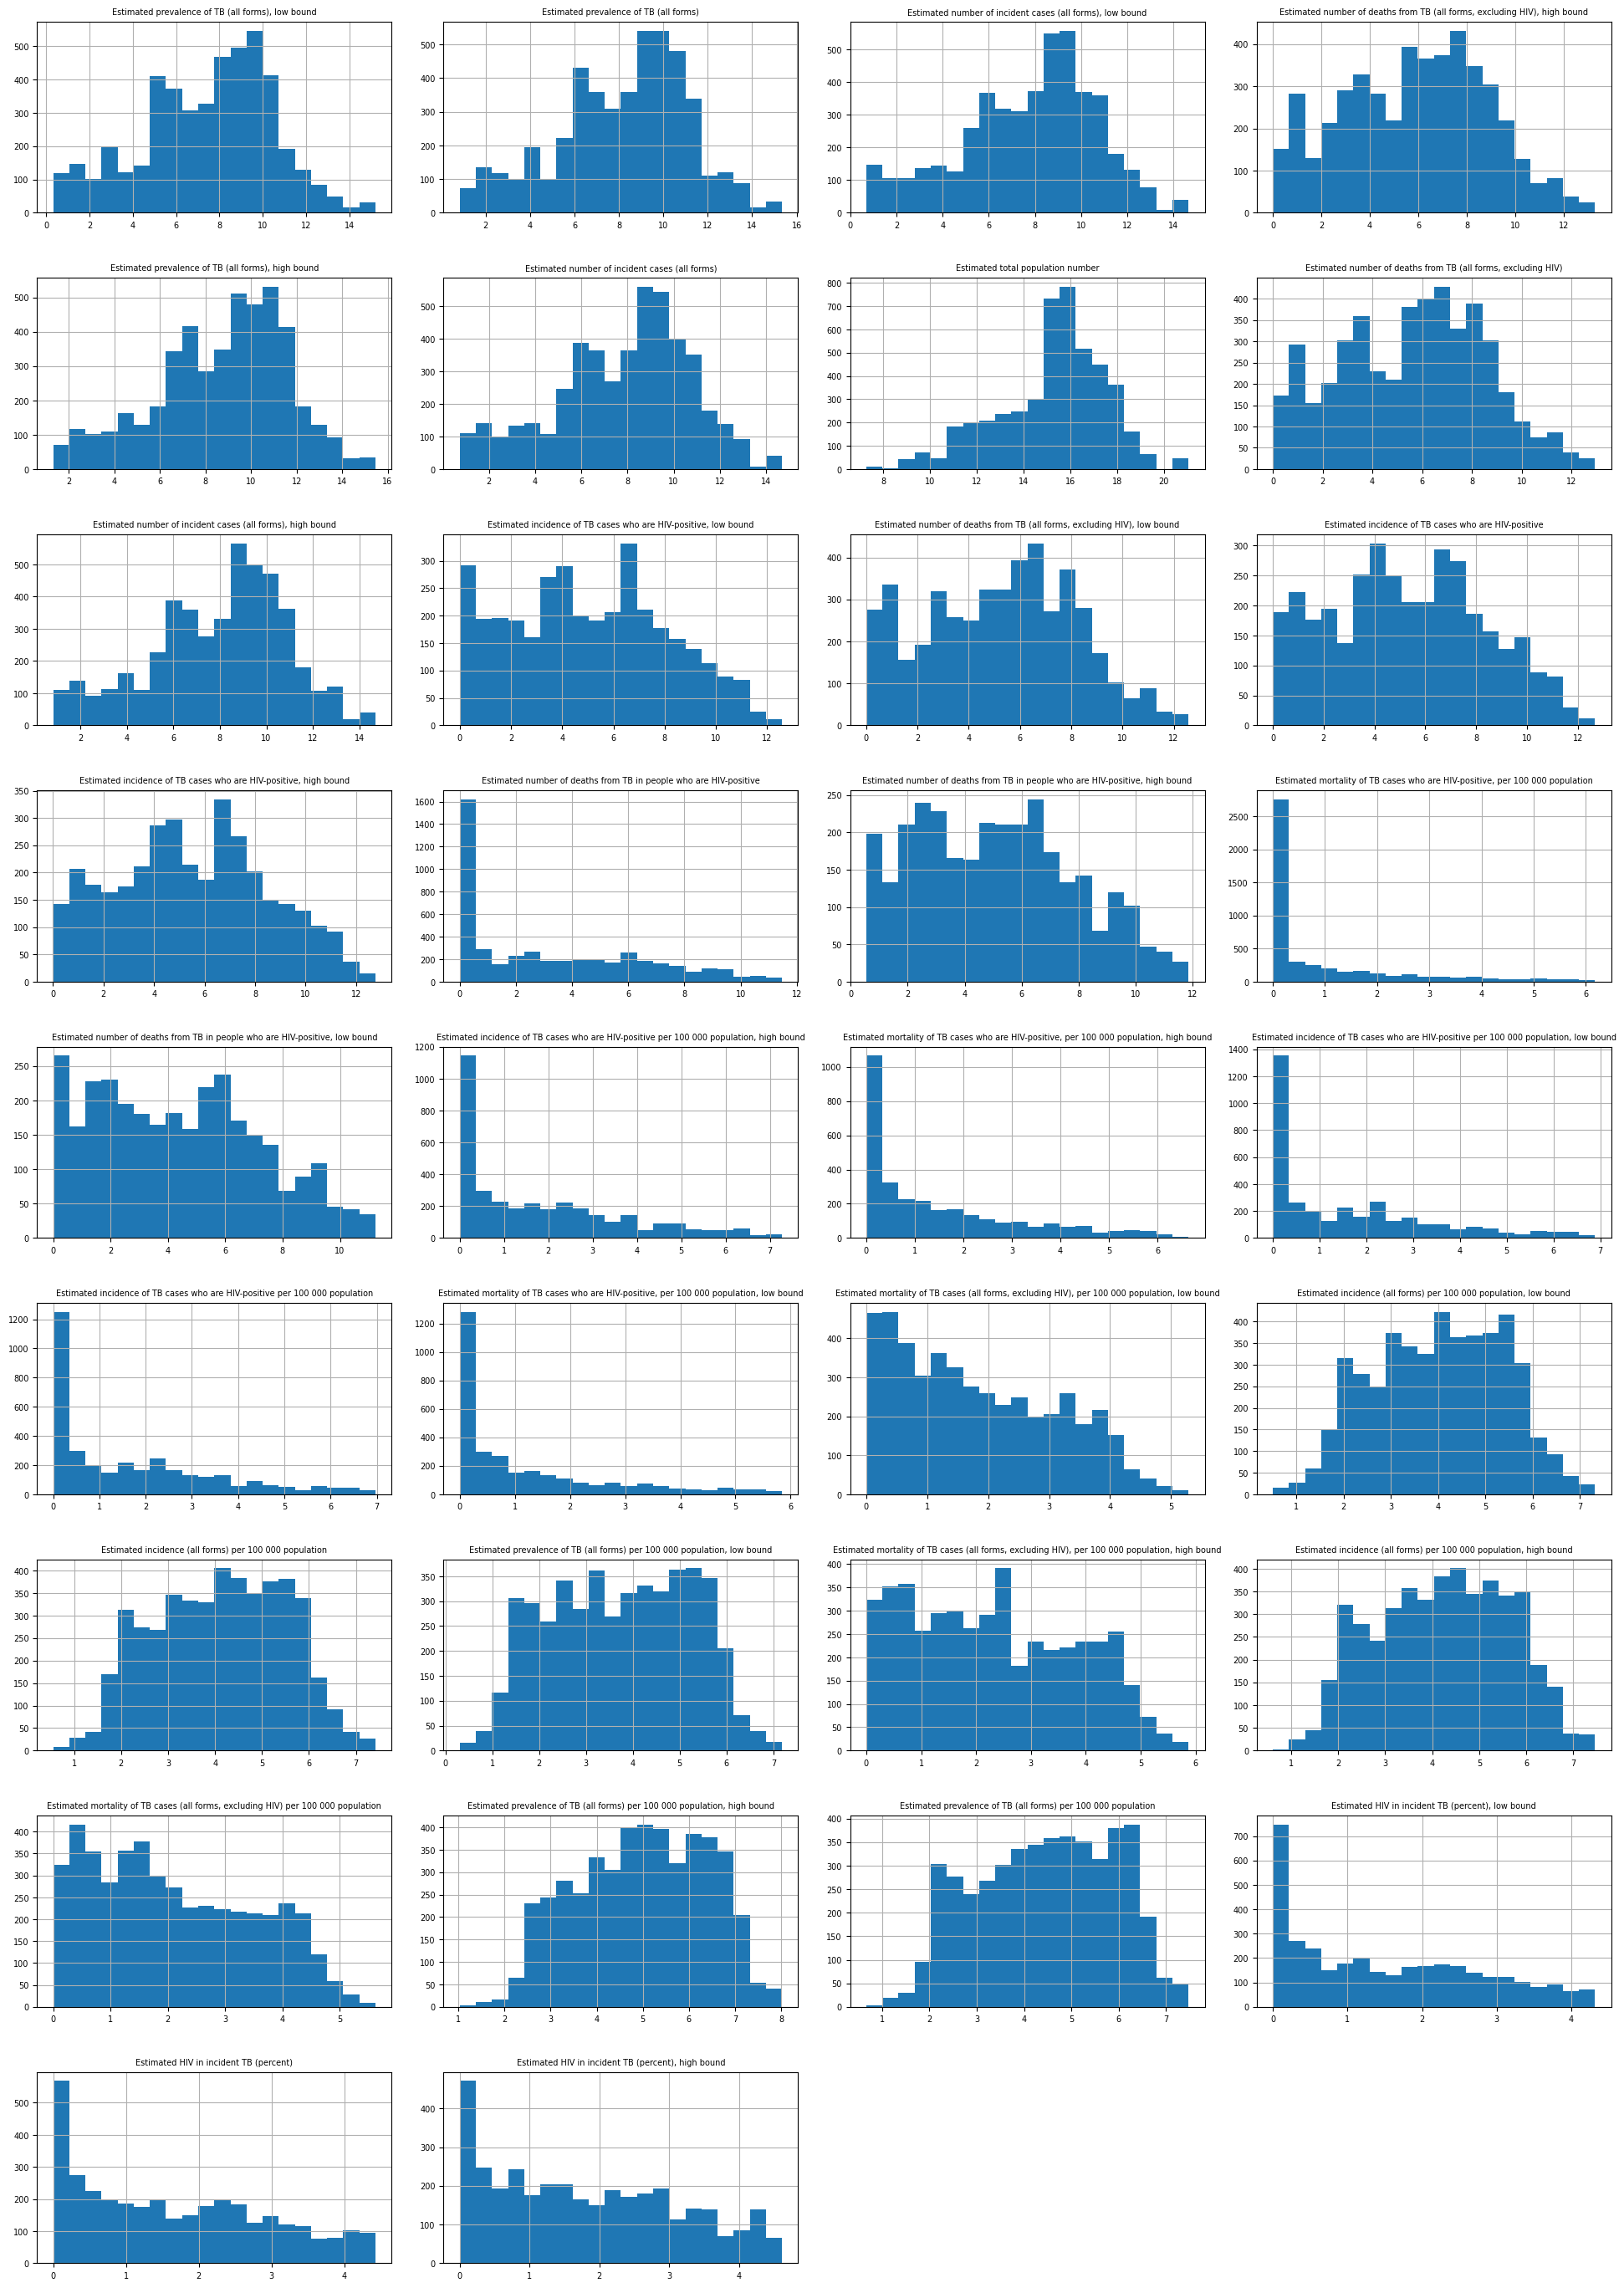

In [22]:
axes = turb_by_country[skewed_cols].hist(figsize=(20, 28), bins=20, layout=(9, 4))

for ax in axes.flatten():
    if ax.get_title():
        ax.set_title(ax.get_title(), fontsize=7, wrap=True)
        ax.tick_params(labelsize=7)

plt.tight_layout(pad=3.0, w_pad=2.0, h_pad=3.0)
plt.show()


**Check Target Balance**

After cleaning, log transformation, and column dropping, the target
distribution remains unchanged from the original cleaned dataset:

    turb_by_country['target'].value_counts()
    → 1 (high detection rate): 2,640 rows (57%)
    → 0 (low detection rate):  2,031 rows (43%)

No rows were lost during the transformation steps, confirming those
operations only affected column values, not row count. The 57/43 split
represents mild class imbalance — not severe enough to require resampling
at this stage, but worth monitoring in the evaluation step when reviewing
per-class F1 scores.



In [23]:
turb_by_country['target'].value_counts()

,count
target,
1,2640
0,2031


**Check Correlation Between Features**

Gaussian Naive Bayes assumes features are conditionally independent given
the class. The correlation matrix checks this assumption — a result above
0.8 between two features suggests they are not independent and may be
redundant with each other:

    numeric_df = turb_by_country.select_dtypes(include='number')
    corr_matrix = numeric_df.corr()
    (corr_matrix.abs() > 0.8).any().any()

select_dtypes(include='number') is required before calling .corr() —
calling it on the full dataframe raises a ValueError since pandas cannot
compute correlation on string columns (country names, region codes,
methodology labels). Note that this True/False check will almost always
return True due to the diagonal (every column is perfectly correlated
with itself at 1.0). The follow-up step identifies which pairs of
different columns are actually problematic.

In [24]:
numeric_df = turb_by_country.select_dtypes(include='number')
corr_matrix = numeric_df.corr()
corr_matrix['target'].sort_values(ascending=False)

,target
target,1.000000
"Case detection rate (all forms), percent, low bound",0.792043
"Case detection rate (all forms), percent",0.789849
"Case detection rate (all forms), percent, high bound",0.740041
Year,0.102683
ISO numeric country/territory code,0.006989
Estimated total population number,-0.193745
"Estimated HIV in incident TB (percent), low bound",-0.230997
Estimated HIV in incident TB (percent),-0.249627
"Estimated HIV in incident TB (percent), high bound",-0.258594


**Correlation Check Results — Multicollinearity Confirmed**

The correlation check confirms severe multicollinearity: 308 column pairs
show correlations above 0.8, primarily between each metric's central
estimate and its low/high uncertainty bounds (e.g., incident cases vs.
incident cases high bound, at 0.9997). This directly violates GNB's
conditional independence assumption — feeding the model three near-identical
columns for the same metric triple-counts that signal rather than adding
new information.

To address this, 24 redundant low/high bound columns were dropped, keeping
only the central estimate for each metric. Column count reduced from 47 to 23.

In [25]:
corr_matrix = turb_by_country.select_dtypes(include='number').corr()

high_corr = corr_matrix.where(
    (corr_matrix.abs() > 0.8) & (corr_matrix.abs() < 1.0)
).stack().sort_values(ascending=False)

print(high_corr)

Estimated number of incident cases (all forms)                                           Estimated number of incident cases (all forms), high bound                       0.999732
Estimated number of incident cases (all forms), high bound                               Estimated number of incident cases (all forms)                                   0.999732
Estimated number of incident cases (all forms)                                           Estimated number of incident cases (all forms), low bound                        0.999612
Estimated number of incident cases (all forms), low bound                                Estimated number of incident cases (all forms)                                   0.999612
Estimated prevalence of TB (all forms)                                                   Estimated prevalence of TB (all forms), high bound                               0.999409
                                                                                                         

### Drop Redundant Low/High Bound Columns

24 columns containing 'low bound' or 'high bound' in their name are
dropped, keeping only the central estimate for each metric family
(prevalence, incidence, mortality, HIV-related, case detection rate).
This directly addresses the multicollinearity confirmed in the previous
step, reducing the column count from 47 to 23 while preserving all
meaningful predictive signal:

    cols_to_drop = [col for col in turb_by_country.columns
                    if 'low bound' in col or 'high bound' in col]
    turb_by_country = turb_by_country.drop(columns=cols_to_drop)
    turb_by_country.shape  # → (4671, 23)


In [26]:
# Step 9 (or next step) — Drop redundant low/high bound columns identified via correlation check
cols_to_drop = [col for col in turb_by_country.columns if 'low bound' in col or 'high bound' in col]

print(f"Dropping {len(cols_to_drop)} redundant columns:")
print(cols_to_drop)

turb_by_country = turb_by_country.drop(columns=cols_to_drop)
print(turb_by_country.shape)

Dropping 24 redundant columns:
['Estimated prevalence of TB (all forms) per 100 000 population, low bound', 'Estimated prevalence of TB (all forms) per 100 000 population, high bound', 'Estimated prevalence of TB (all forms), low bound', 'Estimated prevalence of TB (all forms), high bound', 'Estimated mortality of TB cases (all forms, excluding HIV), per 100 000 population, low bound', 'Estimated mortality of TB cases (all forms, excluding HIV), per 100 000 population, high bound', 'Estimated number of deaths from TB (all forms, excluding HIV), low bound', 'Estimated number of deaths from TB (all forms, excluding HIV), high bound', 'Estimated mortality of TB cases who are HIV-positive, per 100 000 population, low bound', 'Estimated mortality of TB cases who are HIV-positive, per 100 000 population, high bound', 'Estimated number of deaths from TB in people who are HIV-positive, low bound', 'Estimated number of deaths from TB in people who are HIV-positive, high bound', 'Estimated incid

**Confirm Remaining Columns After Drop**

After removing the 24 redundant bound columns, verify what remains:

    turb_by_country.columns.tolist()

This confirms the 23 remaining columns consist of central-estimate
metrics only (prevalence, mortality, incidence, HIV co-infection,
case detection rate), plus identifier columns (country name, region,
ISO codes, year, methodology labels) and target — all of which will
be further filtered in the next step before modeling.

In [27]:
turb_by_country.columns.tolist()

['Country or territory name',
 'ISO 2-character country/territory code',
 'ISO 3-character country/territory code',
 'ISO numeric country/territory code',
 'Region',
 'Year',
 'Estimated total population number',
 'Estimated prevalence of TB (all forms) per 100 000 population',
 'Estimated prevalence of TB (all forms)',
 'Method to derive prevalence estimates',
 'Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population',
 'Estimated number of deaths from TB (all forms, excluding HIV)',
 'Estimated mortality of TB cases who are HIV-positive, per 100 000 population',
 'Estimated number of deaths from TB in people who are HIV-positive',
 'Method to derive mortality estimates',
 'Estimated incidence (all forms) per 100 000 population',
 'Estimated number of incident cases (all forms)',
 'Method to derive incidence estimates',
 'Estimated HIV in incident TB (percent)',
 'Estimated incidence of TB cases who are HIV-positive per 100 000 population',
 'Estimated incide


**Dropping noise and creating dummy columns**

*Why:* Identifier columns (country name, ISO codes) and methodology columns
(how WHO derived each estimate) carry no real predictive signal and risk
leaking information about data collection rather than disease burden.
`Region` was kept and one-hot encoded, since geographic/health-system
clustering is plausibly informative and ties to the health-systems framing
of this analysis.

In [28]:
# Drop identifier and method columns (no predictive value, risk of leakage)
cols_to_drop_final = [
    'Country or territory name',
    'ISO 2-character country/territory code',
    'ISO 3-character country/territory code',
    'ISO numeric country/territory code',
    'Method to derive prevalence estimates',
    'Method to derive mortality estimates',
    'Method to derive incidence estimates'
]

turb_by_country = turb_by_country.drop(columns=cols_to_drop_final)
print(turb_by_country.shape)

# One-hot encode Region
turb_by_country = pd.get_dummies(turb_by_country, columns=['Region'], drop_first=True)
print(turb_by_country.shape)
print(turb_by_country.columns.tolist())

(4671, 16)
(4671, 20)
['Year', 'Estimated total population number', 'Estimated prevalence of TB (all forms) per 100 000 population', 'Estimated prevalence of TB (all forms)', 'Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population', 'Estimated number of deaths from TB (all forms, excluding HIV)', 'Estimated mortality of TB cases who are HIV-positive, per 100 000 population', 'Estimated number of deaths from TB in people who are HIV-positive', 'Estimated incidence (all forms) per 100 000 population', 'Estimated number of incident cases (all forms)', 'Estimated HIV in incident TB (percent)', 'Estimated incidence of TB cases who are HIV-positive per 100 000 population', 'Estimated incidence of TB cases who are HIV-positive', 'Case detection rate (all forms), percent', 'target', 'Region_AMR', 'Region_EMR', 'Region_EUR', 'Region_SEA', 'Region_WPR']


## Modeling — Gaussian Naive Bayes

With the dataset cleaned, transformed, and reduced to 23 meaningful
columns, the modeling phase begins. The steps below cover feature/target
separation, train/test splitting, missing value imputation, model training,
cross-validation, and evaluation.

Gaussian Naive Bayes is chosen as the initial classifier because:
- It is well-suited to continuous numeric features with roughly normal
  distributions (addressed via log transformation in EDA)
- It is computationally efficient on datasets of this size
- It produces interpretable probability estimates per prediction, not
  just binary outputs
- It serves as a strong baseline classifier before considering more
  complex models

In [29]:
X = turb_by_country.drop(columns=['target'])
y = turb_by_country['target']
print(X.shape)
print(y.shape)

(4671, 19)
(4671,)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)

(3736, 19)
(935, 19)


In [31]:
X_train.isnull().sum().sort_values(ascending=False)

,0
Estimated incidence of TB cases who are HIV-positive,919
Estimated incidence of TB cases who are HIV-positive per 100 000 population,919
Estimated HIV in incident TB (percent),919
Estimated prevalence of TB (all forms) per 100 000 population,0
Estimated total population number,0
Year,0
Estimated prevalence of TB (all forms),0
"Estimated mortality of TB cases who are HIV-positive, per 100 000 population",0
Estimated number of deaths from TB in people who are HIV-positive,0
"Estimated number of deaths from TB (all forms, excluding HIV)",0



**Impute missing HIV-related values**
Impute and add median values to null coulumns
*Why:* The three HIV co-infection columns had ~919 missing values each (about 25%
of the training set). Rather than drop these rows or columns and lose data, median
imputation was used (median chosen over mean since these columns are still moderately
skewed). The imputer was fit only on training data and then applied to both train
and test sets to avoid data leakage.

In [32]:
from sklearn.impute import SimpleImputer

hiv_cols = [
    'Estimated incidence of TB cases who are HIV-positive',
    'Estimated incidence of TB cases who are HIV-positive per 100 000 population',
    'Estimated HIV in incident TB (percent)'
]

imputer = SimpleImputer(strategy='median')

# Fit ONLY on training data — this calculates the median from X_train
imputer.fit(X_train[hiv_cols])

# Apply that same training-derived median to both train and test
X_train[hiv_cols] = imputer.transform(X_train[hiv_cols])
X_test[hiv_cols] = imputer.transform(X_test[hiv_cols])

# Confirm no NaNs remain
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


**Fit Gaussian Naive Bayes Model**

The model is trained on X_train and y_train. During fitting, GaussianNB
calculates the mean and variance of each feature separately for each class
(high detection = 1, low detection = 0). These learned parameters define
the normal distribution the model assumes for each feature, and are used
at prediction time to calculate the probability that a new row belongs to
each class:

    from sklearn.naive_bayes import GaussianNB

    model = GaussianNB()
    model.fit(X_train, y_train)

No hyperparameters are tuned at this stage — GaussianNB's defaults are
appropriate for a first-pass binary classifier on this dataset. The model
fits in under a second on 3,736 training rows across 19 features.

In [33]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)


GaussianNB()

In [40]:
y_pred = model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8299465240641711

Confusion Matrix:
 [[321  86]
 [ 73 455]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.79      0.80       407
           1       0.84      0.86      0.85       528

    accuracy                           0.83       935
   macro avg       0.83      0.83      0.83       935
weighted avg       0.83      0.83      0.83       935



### Added dummy test to see if model would beat the score of most selected y low or high detection rate = 0 and 1.  Dummy would select 1 everytime but model predicted accuratly 26% points, better at prediction then the dummy guess.

In [41]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print("Dummy accuracy:", dummy.score(X_test, y_test))   # ~0.57
print("GNB accuracy:  ", model.score(X_test, y_test))    # ~0.83

Dummy accuracy: 0.5647058823529412
GNB accuracy:   0.8299465240641711


### Confusion Matrix — Visual Evaluation

The confusion matrix breaks down model predictions into four categories:
true positives, true negatives, false positives, and false negatives.
Seaborn's heatmap renders these as a color-coded grid — darker cells
indicate higher counts, so a well-performing model should show the
diagonal (correct predictions) visually dominating the off-diagonal
(errors):

    sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True, fmt='d', cmap='Blues')

Results for this model:
- 321 true negatives  (correctly predicted low detection)
- 455 true positives  (correctly predicted high detection)
- 86  false positives (predicted high detection, actually low)
- 73  false negatives (predicted low detection, actually high)

Errors are roughly balanced between the two types (86 vs 73),
confirming the model is not systematically biased toward either class.

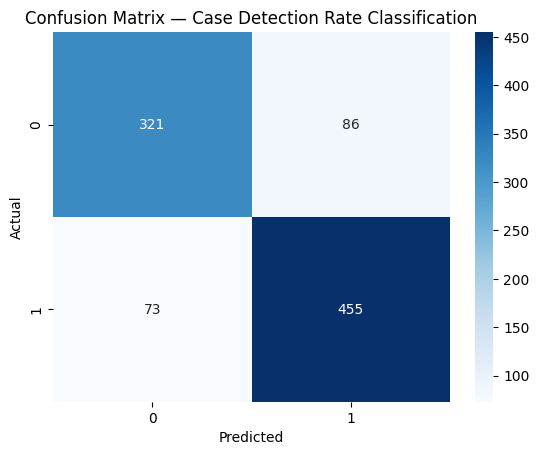

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Case Detection Rate Classification')
plt.show()

**Cross-Validation — Stability Check**

5-fold cross-validation was used to verify the model's stability. Across
the five folds, accuracy scores ranged narrowly from 81.8% to 84.2%,
with a mean of 83.1%. This is virtually identical to the 82.99% accuracy
observed on the original train/test split — confirming the result is
consistent and not the product of a lucky split. Low variance across folds
indicates the model performs reliably regardless of which portion of the
data is used for training versus testing.

In [37]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train, y_train, cv=5)
print(scores)
print(scores.mean())

[0.84090909 0.82463186 0.82864793 0.84203481 0.81793842]
0.8308324205914566


**Predicted Probabilities — Inside the Model's Decision**

Gaussian Naive Bayes does not simply output 0 or 1 — every prediction
is calculated as a probability pair [P(class 0), P(class 1)] that sums
to 1.0. predict_proba() exposes these probabilities directly, rather
than just the final binary guess that predict() returns.

Values are displayed in scientific notation: the number after 'e-'
indicates how many places to shift the decimal point to the left.
For example, 1.07797319e-01 becomes 0.1077 (shift one place left),
and 8.92202681e-01 becomes 0.8922 (shift one place left).

For row 1: [0.1077, 0.8922] — a 10.77% chance of class 0 and an
89.22% chance of class 1. The model predicts class 1 with relatively
high confidence for this row. Rows closer to [0.50, 0.50] represent
genuine uncertainty in the model's assessment.

In [38]:
probabilities = model.predict_proba(X_test)
print(probabilities[:10])  # first 10 rows

[[1.07797319e-01 8.92202681e-01]
 [9.99975152e-01 2.48477569e-05]
 [5.06704687e-11 1.00000000e+00]
 [4.74500913e-01 5.25499087e-01]
 [9.70159040e-01 2.98409602e-02]
 [4.17161404e-01 5.82838596e-01]
 [1.00000000e+00 2.70167069e-18]
 [1.32650474e-05 9.99986735e-01]
 [9.99071007e-01 9.28992953e-04]
 [1.30764987e-04 9.99869235e-01]]


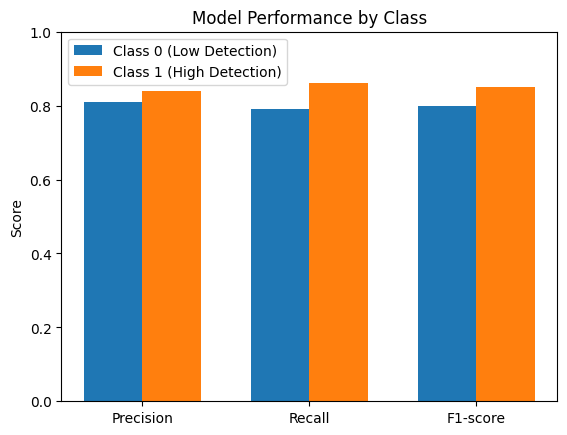

In [39]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Precision', 'Recall', 'F1-score']
class_0 = [0.81, 0.79, 0.80]
class_1 = [0.84, 0.86, 0.85]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, class_0, width, label='Class 0 (Low Detection)')
plt.bar(x + width/2, class_1, width, label='Class 1 (High Detection)')
plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Model Performance by Class')
plt.legend()
plt.ylim(0, 1)
plt.show()

#Predicted Probabilities — Inside the Model's Decision

Gaussian Naive Bayes does not simply output 0 or 1 — every prediction
is calculated as a probability pair [P(class 0), P(class 1)] that sums
to 1.0. predict_proba() exposes these probabilities directly, rather
than just the final binary guess that predict() returns.

Values are displayed in scientific notation: the number after 'e-'
indicates how many places to shift the decimal point to the left.
For example, 1.07797319e-01 becomes 0.1077 (shift one place left),
and 8.92202681e-01 becomes 0.8922 (shift one place left).

For row 1: [0.1077, 0.8922] — a 10.77% chance of class 0 and an
89.22% chance of class 1. The model predicts class 1 with relatively
high confidence for this row. Rows closer to [0.50, 0.50] represent
genuine uncertainty in the model's assessment.

## Predicted Probabilities — Inside the Model's Decision

Gaussian Naive Bayes does not simply output 0 or 1 — every prediction
is calculated as a probability pair [P(class 0), P(class 1)] that sums
to 1.0. predict_proba() exposes these probabilities directly, rather
than just the final binary guess that predict() returns.

Values are displayed in scientific notation: the number after 'e-'
indicates how many places to shift the decimal point to the left.
For example, 1.07797319e-01 becomes 0.1077 (shift one place left),
and 8.92202681e-01 becomes 0.8922 (shift one place left).

For row 1: [0.1077, 0.8922] — a 10.77% chance of class 0 and an
89.22% chance of class 1. The model predicts class 1 with relatively
high confidence for this row. Rows closer to [0.50, 0.50] represent
genuine uncertainty in the model's assessment.

## Key Decisions in EDA and Preparation
- Log transformation (log1p) applied to 34 skewed columns, reducing
  skewness from a range of 0 to +10.6 down to -0.6 to +1.8
- 308 column pairs found with correlation above 0.8, primarily between
  each metric's central estimate and its uncertainty bounds — 24 redundant
  low/high bound columns dropped
- Identifier and methodology columns dropped (no predictive signal,
  leakage risk); Region one-hot encoded (5 dummy columns, AFR as baseline)
- Three HIV co-infection columns had ~919 missing values each — median
  imputation applied, fit on training data only to prevent data leakage

## Model Performanc
Gaussian Naive Bayes, trained on 3,736 rows, evaluated on 935:
- Accuracy: 83.0% (vs. 57% majority-class baseline)
- Class 0 F1: 0.80 | Class 1 F1: 0.85
- Confusion matrix: 321 TN, 455 TP, 86 FP, 73 FN
- 5-fold cross-validation mean: 83.1% (range 81.8%–84.2%) — stable,
  consistent with single-split result, not a lucky draw

## What I Would Try Next
- Compare GNB against logistic regression or random forest on the same
  feature set to benchmark performance
- Investigate which countries/regions drive the 159 misclassified rows
- Explore whether adding time as a structured feature (year-over-year
  trend) improves prediction
- Revisit HIV co-infection columns with a more principled imputation
  strategy (e.g. KNN imputation by region)